# 04 — Comparación de poses y trayectorias

## 1. Objetivo y alcance

El objetivo de este notebook es comparar las variables corporales del video de
referencia con las de un video de ejecución para identificar diferencias
interpretables en la postura y el movimiento.

Se analizarán:

- coordenadas corporales normalizadas;
- ángulos articulares;
- desplazamientos por articulación;
- similitud por frame;
- similitud por parte del cuerpo;
- trayectorias articulares;
- diferencias entre brazos, piernas, torso y cabeza.

El resultado será una primera medición técnica de las diferencias corporales
entre ambas secuencias. La alineación temporal mediante DTW, el score general
y las reglas de retroalimentación se implementarán en notebooks posteriores.

## 2. Datos de entrada y contrato de comparación

La comparación utilizará los archivos derivados del Notebook 03. Cada
secuencia deberá contar con variables corporales calculadas a partir de los
landmarks detectados.

Cada frame deberá incluir:

- `frame_index`;
- `timestamp_sec`;
- landmarks normalizados;
- ángulos articulares;
- velocidades de movimiento;
- parte corporal;
- visibilidad o confianza;
- indicador de detección.

La comparación inicial asumirá una correspondencia directa entre frames de
referencia y ejecución. Esta decisión permite validar primero las métricas
corporales sin introducir todavía una alineación temporal compleja.

La alineación de secuencias realizadas a distinta velocidad se implementará
posteriormente mediante DTW en el Notebook 05.

In [39]:
import json
import math
from collections import defaultdict
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import mediapipe as mp

PROJECT_ROOT = Path.cwd().parent
FEATURES_DIR = PROJECT_ROOT / "data" / "derived" / "features"

reference_feature_files = sorted(FEATURES_DIR.glob("*_features.json"))

if not reference_feature_files:
    raise FileNotFoundError("No se encontraron variables derivadas. Primero debe finalizar correctamente el Notebook 03.")

reference_feature_path = reference_feature_files[0]

with reference_feature_path.open("r", encoding="utf-8") as file:
    reference_feature_data = json.load(file)

expected_feature_groups = {
    "normalized_landmarks",
    "angles",
    "angular_velocity",
    "landmark_velocity",
}

available_feature_groups = set(reference_feature_data["feature_groups"])

missing_feature_groups = (expected_feature_groups - available_feature_groups)

if missing_feature_groups:
    raise ValueError(
        f"Faltan grupos de variables: {missing_feature_groups}"
    )

print(f"Archivo de referencia: {reference_feature_path.name}")
print(f"Frames: {reference_feature_data['frame_count']}")
print(f"Landmarks: {reference_feature_data['landmark_count']}")
print(f"Grupos disponibles: {reference_feature_data['feature_groups']}")

Archivo de referencia: execution_sBM_personal_01_features.json
Frames: 947
Landmarks: 33
Grupos disponibles: ['normalized_landmarks', 'body_parts', 'angles', 'angular_velocity', 'landmark_velocity']


## 3. Disponibilidad y selección de las secuencias

El video de referencia se seleccionará de los archivos normalizados generados
por el Notebook 03.

El video de ejecución será una grabación propia realizada bajo una situación
similar a `sBM`, sin música incorporada. La ausencia de música no impide
comparar las variables corporales, ya que este notebook se concentra en la
geometría y la trayectoria del movimiento.

La comparación inicial considerará:

- una persona;
- cuerpo completo visible;
- cámara relativamente frontal;
- movimiento corporal continuo;
- video de referencia normalizado;
- video de ejecución pendiente de procesar y normalizar.

La sincronización con el ritmo musical y la alineación temporal entre
secuencias se implementarán posteriormente mediante DTW en el Notebook 05.

In [40]:
REFERENCE_DIR = PROJECT_ROOT / "data" / "raw" / "reference"
EXECUTION_DIR = PROJECT_ROOT / "data" / "raw" / "execution"

REFERENCE_VIDEO_NAME = "gPO_sBM_c01_d10_mPO0_ch01.mp4"
reference_video_path = REFERENCE_DIR / REFERENCE_VIDEO_NAME

execution_candidates = sorted(path for path in EXECUTION_DIR.iterdir() if path.is_file() and path.suffix.lower() in {".mp4", ".mov", ".webm", ".avi", ".mkv"})

if not reference_video_path.exists():
    raise FileNotFoundError(f"No se encontró el video de referencia: {reference_video_path}")

if len(execution_candidates) != 1:
    raise ValueError("Debe existir exactamente un video de ejecución. " f"Encontrados: {execution_candidates}")

execution_video_path = execution_candidates[0]

print(f"Referencia: {reference_video_path.name}")
print(f"Ejecución: {execution_video_path.name}")

Referencia: gPO_sBM_c01_d10_mPO0_ch01.mp4
Ejecución: execution_sBM_personal_01.mov


## 4. Inspección técnica de las secuencias

Antes de comparar las variables corporales, se revisarán las características
básicas de los videos de referencia y ejecución.

Se comprobarán:

- existencia y formato de los archivos;
- apertura correcta mediante OpenCV;
- cantidad de frames;
- FPS;
- resolución;
- duración;
- compatibilidad temporal de las secuencias.

Esta inspección permite identificar diferencias de captura antes de calcular
las métricas corporales.

In [41]:
def inspect_video(video_path):
    capture = cv2.VideoCapture(str(video_path))

    if not capture.isOpened():
        raise RuntimeError(f"No fue posible abrir el video: {video_path}")

    fps = capture.get(cv2.CAP_PROP_FPS)
    frame_count = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))

    capture.release()

    duration_sec = frame_count / fps if fps > 0 else None

    return {
        "file_name": video_path.name,
        "extension": video_path.suffix.lower(),
        "frame_count": frame_count,
        "fps": round(fps, 3),
        "width": width,
        "height": height,
        "duration_sec": round(duration_sec, 3)
    }


reference_inventory = inspect_video(reference_video_path)
execution_inventory = inspect_video(execution_video_path)

print("Referencia:")
print(reference_inventory)

print("\nEjecución:")
print(execution_inventory)

Referencia:
{'file_name': 'gPO_sBM_c01_d10_mPO0_ch01.mp4', 'extension': '.mp4', 'frame_count': 719, 'fps': 59.94, 'width': 1920, 'height': 1080, 'duration_sec': 11.995}

Ejecución:
{'file_name': 'execution_sBM_personal_01.mov', 'extension': '.mov', 'frame_count': 947, 'fps': 59.975, 'width': 360, 'height': 640, 'duration_sec': 15.79}


## Resultado de la inspección técnica

Ambos videos pueden abrirse correctamente y contienen una frecuencia de
captura cercana a 60 FPS.

La referencia tiene una duración aproximada de 12 segundos, mientras que la
ejecución dura aproximadamente 15.8 segundos. Esta diferencia no impide una
primera comparación, pero sí significa que los frames no pueden emparejarse
directamente durante toda la secuencia.

La ejecución está grabada en formato vertical, a diferencia de la referencia
horizontal. Por ello, la comparación no utilizará los píxeles originales,
sino las coordenadas corporales normalizadas obtenidas a partir de los
landmarks.

La diferencia de duración y velocidad temporal se resolverá posteriormente
mediante alineación temporal con DTW en

## 5. Comparación de coordenadas normalizadas

Se cargarán las variables derivadas del video de referencia y del video de
ejecución.

La primera comparación utilizará las coordenadas normalizadas de los
landmarks. Estas coordenadas ya fueron centradas respecto al cuerpo y
escaladas con base en la distancia entre hombros y caderas.

Como las secuencias tienen distinta duración, inicialmente se inspeccionará
su estructura sin asumir todavía una alineación temporal completa. La
alineación mediante DTW se implementará posteriormente en el Notebook 05.

In [42]:
REFERENCE_FEATURES_PATH = (PROJECT_ROOT / "data" / "derived" / "features" / "gPO_sBM_c01_d10_mPO0_ch01_features.json")

EXECUTION_FEATURES_PATH = (PROJECT_ROOT/ "data" / "derived" / "features" / "execution_sBM_personal_01_features.json")

with REFERENCE_FEATURES_PATH.open("r", encoding="utf-8") as file:
    reference_features = json.load(file)

with EXECUTION_FEATURES_PATH.open("r", encoding="utf-8") as file:
    execution_features = json.load(file)

if reference_features["video_role"] != "reference":
    raise ValueError("El archivo seleccionado no es de referencia")

if execution_features["video_role"] != "execution":
    raise ValueError("El archivo seleccionado no es de ejecución")

if reference_features["landmark_count"] != 33:
    raise ValueError("La referencia no contiene 33 landmarks")

if execution_features["landmark_count"] != 33:
    raise ValueError("La ejecución no contiene 33 landmarks")

print("Referencia:")
print(f"- {reference_features['source_video']}")
print(f"- Frames: {reference_features['frame_count']}")
print(f"- FPS: {reference_features['fps']}")

print("\nEjecución:")
print(f"- {execution_features['source_video']}")
print(f"- Frames: {execution_features['frame_count']}")
print(f"- FPS: {execution_features['fps']}")

print("\nGrupos comparables:")
print(reference_features["feature_groups"])

Referencia:
- gPO_sBM_c01_d10_mPO0_ch01.mp4
- Frames: 719
- FPS: 59.94

Ejecución:
- execution_sBM_personal_01.mov
- Frames: 947
- FPS: 59.97466751108296

Grupos comparables:
['normalized_landmarks', 'body_parts', 'angles', 'angular_velocity', 'landmark_velocity']


## 6. Preparación de la comparación por frame

Las secuencias tienen distinta cantidad de frames. Para realizar una primera
comparación técnica se identificarán los índices de frame presentes en ambas
secuencias y con detección válida.

Esta comparación directa no representa todavía una alineación temporal
definitiva. Su propósito es inspeccionar el comportamiento de las métricas
antes de aplicar DTW.

In [43]:
reference_frames_by_index = {frame["frame_index"]: frame for frame in reference_features["frames"]}

execution_frames_by_index = {frame["frame_index"]: frame for frame in execution_features["frames"]}

common_frame_indices = sorted(set(reference_frames_by_index) & set(execution_frames_by_index))

comparable_frame_indices = [
    frame_index
    for frame_index in common_frame_indices
    if (
        reference_frames_by_index[frame_index]["detected"]
        and execution_frames_by_index[frame_index]["detected"]
        and reference_frames_by_index[frame_index]["landmarks"] is not None
        and execution_frames_by_index[frame_index]["landmarks"] is not None
    )
]

print(f"Frames de referencia: {len(reference_frames_by_index)}")
print(f"Frames de ejecución: {len(execution_frames_by_index)}")
print(f"Frames con índice común: {len(common_frame_indices)}")
print(f"Frames comparables: {len(comparable_frame_indices)}")
print("Primer frame comparable:", comparable_frame_indices[0] if comparable_frame_indices else None)
print("Último frame comparable:", comparable_frame_indices[-1] if comparable_frame_indices else None)

Frames de referencia: 719
Frames de ejecución: 947
Frames con índice común: 719
Frames comparables: 719
Primer frame comparable: 0
Último frame comparable: 718


## 7. Diferencia de coordenadas normalizadas

Para cada frame comparable se calculará la distancia euclidiana entre cada
landmark de la referencia y el landmark correspondiente de la ejecución.

La distancia utilizará las coordenadas normalizadas `x`, `y` y `z`. Un valor
pequeño indica que los landmarks ocupan posiciones similares dentro del
cuerpo; un valor mayor indica una diferencia corporal más amplia.

Estas diferencias se conservarán por landmark, frame y parte del cuerpo.

In [44]:
def landmarks_by_id(frame):
    return {landmark["landmark_id"]: landmark for landmark in frame["landmarks"]}


def euclidean_3d(point_a, point_b):
    return math.sqrt((point_a["x"] - point_b["x"]) ** 2 + (point_a["y"] - point_b["y"]) ** 2 + (point_a["z"] - point_b["z"]) ** 2)


coordinate_difference_records = []

for frame_index in comparable_frame_indices:
    reference_frame = reference_frames_by_index[frame_index]
    execution_frame = execution_frames_by_index[frame_index]

    reference_landmarks = landmarks_by_id(reference_frame)
    execution_landmarks = landmarks_by_id(execution_frame)

    for landmark_id in sorted(reference_landmarks):
        if landmark_id not in execution_landmarks:
            continue

        reference_landmark = reference_landmarks[landmark_id]
        execution_landmark = execution_landmarks[landmark_id]

        coordinate_difference_records.append({
            "frame_index": frame_index,
            "reference_timestamp_sec": reference_frame["timestamp_sec"],
            "execution_timestamp_sec": execution_frame["timestamp_sec"],
            "landmark_id": landmark_id,
            "landmark_name": reference_landmark["landmark_name"],
            "body_part": reference_landmark["body_part"],
            "distance_3d": euclidean_3d(reference_landmark, execution_landmark),
            "reference_visibility": reference_landmark["visibility"],
            "execution_visibility": execution_landmark["visibility"],
        })

difference_by_frame = defaultdict(list)
difference_by_body_part = defaultdict(list)

for record in coordinate_difference_records:
    difference_by_frame[record["frame_index"]].append(record["distance_3d"])
    difference_by_body_part[record["body_part"]].append(record["distance_3d"])

frame_difference_summary = [
    {
        "frame_index": frame_index,
        "mean_distance_3d": sum(values) / len(values),
        "max_distance_3d": max(values),
        "landmarks_compared": len(values),
    }
    for frame_index, values in difference_by_frame.items()
]

body_part_difference_summary = {
    body_part: {
        "mean_distance_3d": sum(values) / len(values),
        "max_distance_3d": max(values),
        "landmarks_compared": len(values),
    }
    for body_part, values in difference_by_body_part.items()
}

print("Registros de diferencias:", len(coordinate_difference_records))
print("Frames resumidos:", len(frame_difference_summary))
print("\nDiferencia promedio por parte del cuerpo:")

for body_part, summary in body_part_difference_summary.items():
    print(body_part, round(summary["mean_distance_3d"], 4))

Registros de diferencias: 23727
Frames resumidos: 719

Diferencia promedio por parte del cuerpo:
head 0.9694
torso 0.9895
left_arm 1.5155
right_arm 1.8408
left_leg 2.8808
right_leg 2.6352


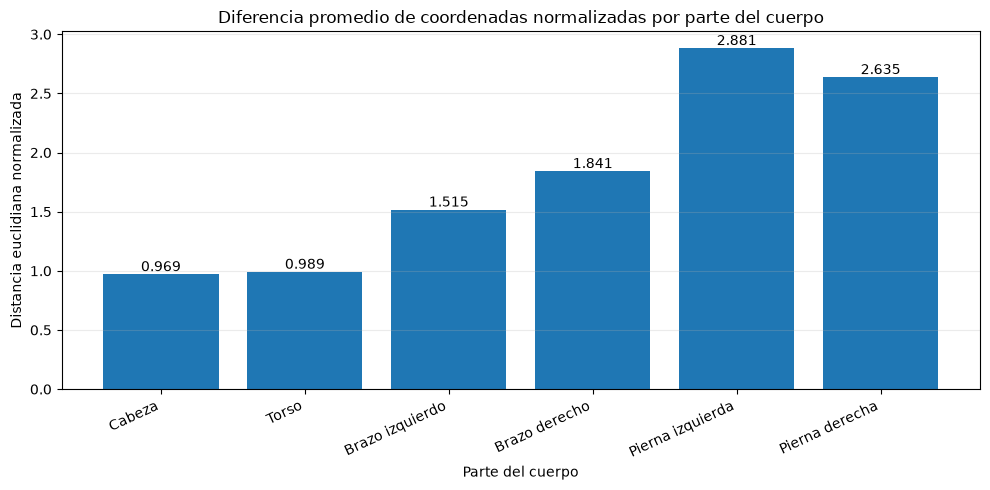

In [45]:
body_part_order = [
    "head",
    "torso",
    "left_arm",
    "right_arm",
    "left_leg",
    "right_leg",
]

body_part_labels = {
    "head": "Cabeza",
    "torso": "Torso",
    "left_arm": "Brazo izquierdo",
    "right_arm": "Brazo derecho",
    "left_leg": "Pierna izquierda",
    "right_leg": "Pierna derecha",
}

body_part_values = [body_part_difference_summary[body_part]["mean_distance_3d"] for body_part in body_part_order]

plt.figure(figsize=(10, 5))

bars = plt.bar([body_part_labels[body_part] for body_part in body_part_order], body_part_values,)

plt.title("Diferencia promedio de coordenadas normalizadas por parte del cuerpo")
plt.ylabel("Distancia euclidiana normalizada")
plt.xlabel("Parte del cuerpo")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.25)
for bar, value in zip(bars, body_part_values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{value:.3f}", ha="center", va="bottom",)
plt.tight_layout()
plt.show()

## 8. Diferencia corporal a lo largo del tiempo

Se observará cómo cambia la diferencia promedio entre referencia y ejecución
durante los frames comparables.

Esta gráfica permite identificar momentos con mayor desviación corporal. La
señal todavía corresponde a una comparación directa por índice de frame, por
lo que debe interpretarse como una inspección preliminar antes de aplicar DTW.

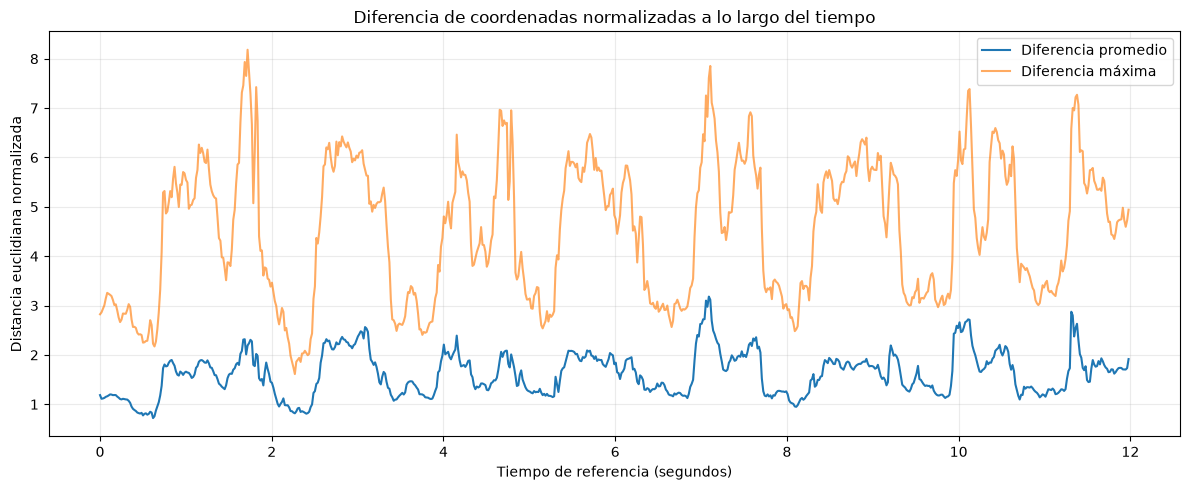

In [46]:
reference_timestamps = [reference_frames_by_index[summary["frame_index"]]["timestamp_sec"] for summary in frame_difference_summary]

mean_frame_differences = [summary["mean_distance_3d"] for summary in frame_difference_summary]

max_frame_differences = [summary["max_distance_3d"] for summary in frame_difference_summary]

plt.figure(figsize=(12, 5))
plt.plot(reference_timestamps, mean_frame_differences, label="Diferencia promedio")
plt.plot(reference_timestamps, max_frame_differences, label="Diferencia máxima", alpha=0.65,)
plt.title("Diferencia de coordenadas normalizadas a lo largo del tiempo")
plt.xlabel("Tiempo de referencia (segundos)")
plt.ylabel("Distancia euclidiana normalizada")
plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()

## 9. Diferencia de ángulos articulares

Además de comparar posiciones, se compararán los ángulos articulares entre
referencia y ejecución.

Para cada articulación se calculará la diferencia absoluta en grados. Esta
métrica ayuda a distinguir si la diferencia corporal proviene de una postura
angular distinta, aunque los landmarks estén relativamente cerca.

La comparación sigue siendo directa por índice de frame y se considera
preliminar hasta aplicar DTW.

In [47]:
angle_difference_records = []

angle_names = sorted({angle_name for frame_index in comparable_frame_indices for angle_name in (set(reference_frames_by_index[frame_index]["angles"]) & set(execution_frames_by_index[frame_index]["angles"]))})

for frame_index in comparable_frame_indices:
    reference_angles = reference_frames_by_index[frame_index]["angles"]
    execution_angles = execution_frames_by_index[frame_index]["angles"]

    for angle_name in angle_names:
        reference_angle = reference_angles.get(angle_name)
        execution_angle = execution_angles.get(angle_name)

        if reference_angle is None or execution_angle is None:
            continue

        angle_difference_records.append({
            "frame_index": frame_index,
            "reference_timestamp_sec": reference_frames_by_index[frame_index]["timestamp_sec"],
            "execution_timestamp_sec": execution_frames_by_index[frame_index]["timestamp_sec"],
            "angle_name": angle_name,
            "reference_angle_deg": reference_angle,
            "execution_angle_deg": execution_angle,
            "absolute_difference_deg": abs(reference_angle - execution_angle)
        })

angle_difference_by_joint = defaultdict(list)

for record in angle_difference_records:
    angle_difference_by_joint[record["angle_name"]].append(record["absolute_difference_deg"])

angle_difference_summary = {
    angle_name: {
        "mean_difference_deg": sum(values) / len(values),
        "max_difference_deg": max(values),
        "frames_compared": len(values),
    }
    for angle_name, values in angle_difference_by_joint.items()
}

print("Registros de diferencias angulares:", len(angle_difference_records),)

for angle_name, summary in angle_difference_summary.items():
    print(angle_name,{"mean_difference_deg": round(summary["mean_difference_deg"], 2), "max_difference_deg": round(summary["max_difference_deg"], 2), "frames_compared": summary["frames_compared"]})

Registros de diferencias angulares: 5752
left_elbow {'mean_difference_deg': 14.26, 'max_difference_deg': 49.62, 'frames_compared': 719}
left_hip {'mean_difference_deg': 6.14, 'max_difference_deg': 46.39, 'frames_compared': 719}
left_knee {'mean_difference_deg': 15.16, 'max_difference_deg': 59.6, 'frames_compared': 719}
left_shoulder {'mean_difference_deg': 32.53, 'max_difference_deg': 79.5, 'frames_compared': 719}
right_elbow {'mean_difference_deg': 18.71, 'max_difference_deg': 115.7, 'frames_compared': 719}
right_hip {'mean_difference_deg': 10.18, 'max_difference_deg': 85.11, 'frames_compared': 719}
right_knee {'mean_difference_deg': 16.05, 'max_difference_deg': 50.83, 'frames_compared': 719}
right_shoulder {'mean_difference_deg': 33.49, 'max_difference_deg': 84.25, 'frames_compared': 719}


### Visualización de diferencias angulares

La siguiente gráfica resume la diferencia angular promedio por articulación.
Permite identificar qué articulaciones presentan mayor variación postural
entre ambas secuencias.

Los valores no representan todavía una severidad definitiva, porque la
comparación temporal aún no ha sido alineada mediante DTW.

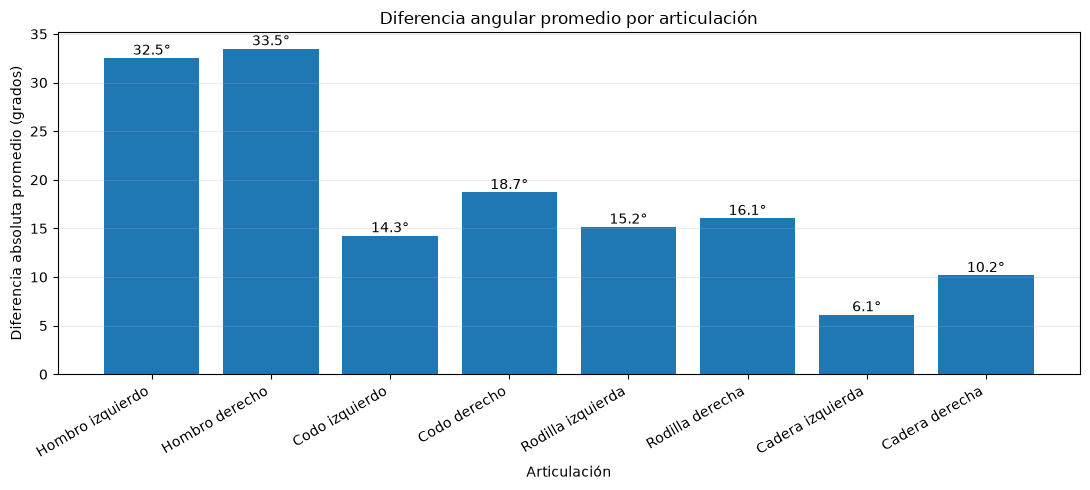

In [48]:
angle_labels = {
    "left_elbow": "Codo izquierdo",
    "right_elbow": "Codo derecho",
    "left_shoulder": "Hombro izquierdo",
    "right_shoulder": "Hombro derecho",
    "left_knee": "Rodilla izquierda",
    "right_knee": "Rodilla derecha",
    "left_hip": "Cadera izquierda",
    "right_hip": "Cadera derecha",
}

angle_order = [
    "left_shoulder",
    "right_shoulder",
    "left_elbow",
    "right_elbow",
    "left_knee",
    "right_knee",
    "left_hip",
    "right_hip",
]

angle_mean_values = [angle_difference_summary[angle_name]["mean_difference_deg"] for angle_name in angle_order]

plt.figure(figsize=(11, 5))

bars = plt.bar([angle_labels[angle_name] for angle_name in angle_order], angle_mean_values)

plt.title("Diferencia angular promedio por articulación")
plt.xlabel("Articulación")
plt.ylabel("Diferencia absoluta promedio (grados)")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.25)
for bar, value in zip(bars, angle_mean_values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{value:.1f}°", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 10. Comparación estática de poses normalizadas

Se visualizará un frame común de ambas secuencias utilizando las coordenadas
normalizadas.

La referencia y la ejecución se mostrarán lado a lado con la misma escala
espacial para facilitar la comparación visual de postura y alineación corporal.

Esta vista corresponde a una comparación directa por índice de

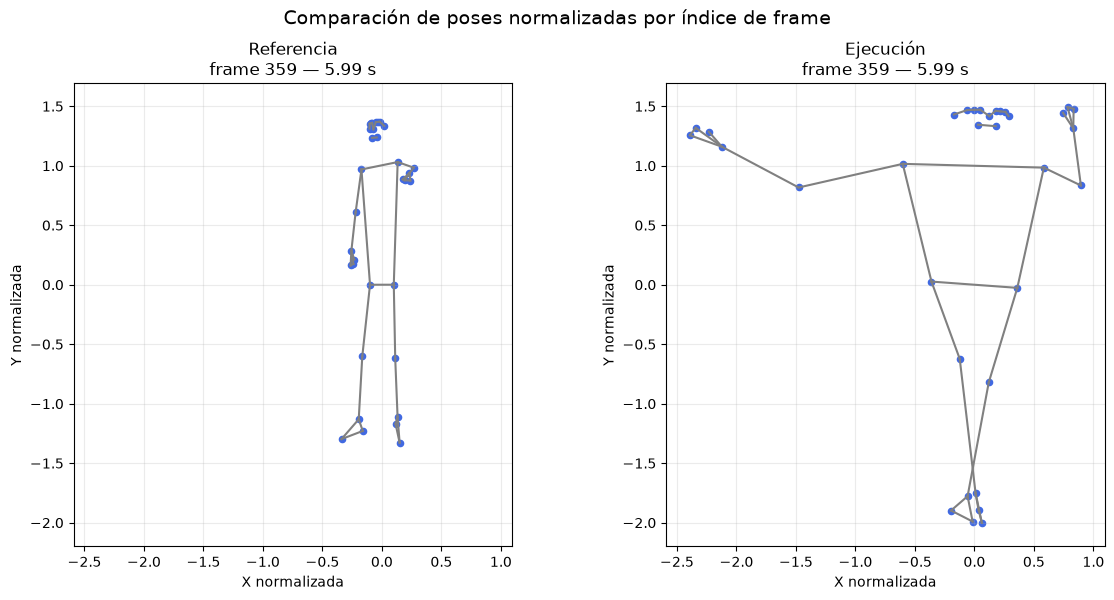

In [49]:
mp_pose = mp.solutions.pose
POSE_CONNECTIONS = list(mp_pose.POSE_CONNECTIONS)

comparison_frame_index = comparable_frame_indices[len(comparable_frame_indices) // 2]

reference_frame = reference_frames_by_index[comparison_frame_index]
execution_frame = execution_frames_by_index[comparison_frame_index]


def plot_normalized_skeleton(axis, frame, title):
    landmarks = landmarks_by_id(frame)

    for start_id, end_id in POSE_CONNECTIONS:
        if start_id not in landmarks or end_id not in landmarks:
            continue

        start = landmarks[start_id]
        end = landmarks[end_id]
        axis.plot([start["x"], end["x"]], [-start["y"], -end["y"]], color="gray", linewidth=1.5)

    axis.scatter([landmark["x"] for landmark in landmarks.values()], [-landmark["y"] for landmark in landmarks.values()], s=20, color="royalblue")
    axis.set_title(title)
    axis.set_xlabel("X normalizada")
    axis.set_ylabel("Y normalizada")
    axis.set_aspect("equal")
    axis.grid(alpha=0.25)


fig, axes = plt.subplots(1, 2, figsize=(12, 6))

plot_normalized_skeleton(axes[0], reference_frame,("Referencia\n" f"frame {comparison_frame_index} — " f"{reference_frame['timestamp_sec']:.2f} s"))

plot_normalized_skeleton(axes[1], execution_frame,( "Ejecución\n" f"frame {comparison_frame_index} — " f"{execution_frame['timestamp_sec']:.2f} s"))

x_values = [landmark["x"] for frame in [reference_frame, execution_frame] for landmark in frame["landmarks"]]

y_values = [-landmark["y"] for frame in [reference_frame, execution_frame] for landmark in frame["landmarks"]]

margin = 0.2

x_min, x_max = min(x_values), max(x_values)
y_min, y_max = min(y_values), max(y_values)

for axis in axes:
    axis.set_xlim(x_min - margin, x_max + margin)
    axis.set_ylim(y_min - margin, y_max + margin)

fig.suptitle("Comparación de poses normalizadas por índice de frame", fontsize=14)
plt.tight_layout()
plt.show()

### Inspección visual preliminar sobre los videos originales

Se mostrará el mismo índice de frame sobre los videos originales de referencia
y ejecución, con los landmarks detectados por MediaPipe.

Esta vista permite comprobar si las diferencias observadas en las coordenadas
normalizadas también son visibles en la imagen original.

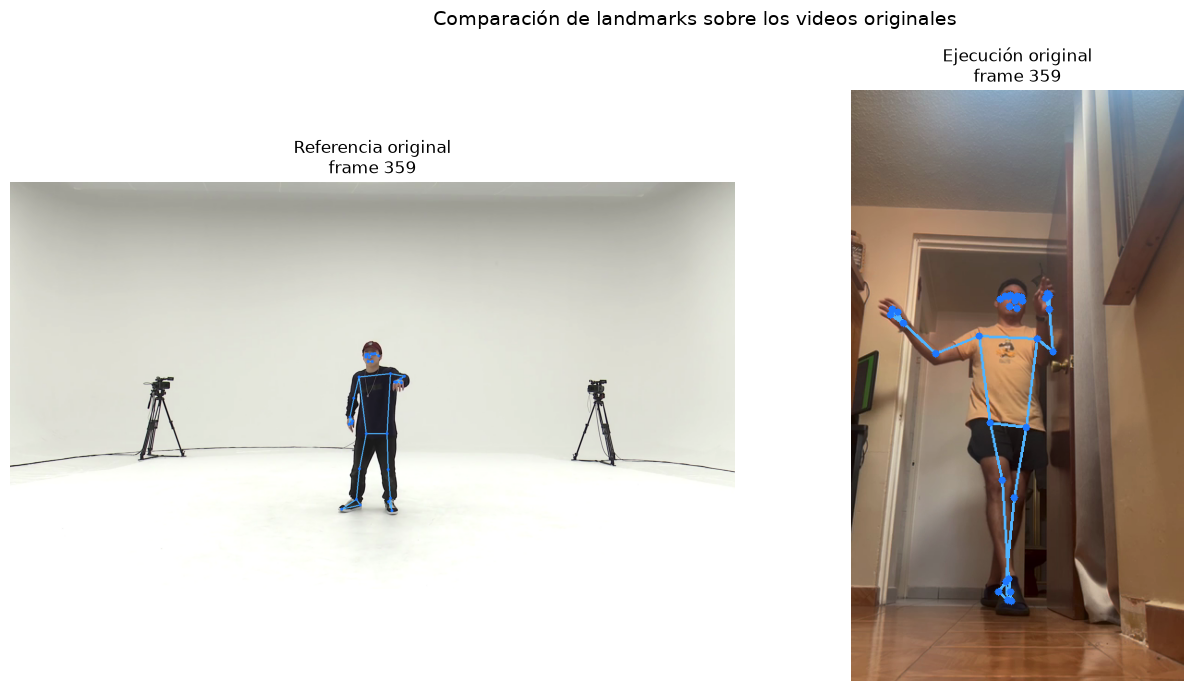

In [51]:
REFERENCE_POSE_PATH = PROJECT_ROOT / "data" / "derived" / "pose" / "gPO_sBM_c01_d10_mPO0_ch01_pose.json"
EXECUTION_POSE_PATH = PROJECT_ROOT / "data" / "derived" / "pose" / "execution_sBM_personal_01_pose.json"

with REFERENCE_POSE_PATH.open("r", encoding="utf-8") as file:
    reference_pose_data = json.load(file)

with EXECUTION_POSE_PATH.open("r", encoding="utf-8") as file:
    execution_pose_data = json.load(file)

reference_raw_frames = {frame["frame_index"]: frame for frame in reference_pose_data["frames"]}
execution_raw_frames = {frame["frame_index"]: frame for frame in execution_pose_data["frames"]}

def read_video_frame(video_path, frame_index):
    capture = cv2.VideoCapture(str(video_path))
    capture.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
    success, frame = capture.read()
    capture.release()
    if not success:
        raise RuntimeError(f"No se pudo leer el frame {frame_index} de {video_path.name}")
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

def draw_pose_on_frame(image, frame):
    annotated_image = image.copy()
    height, width = annotated_image.shape[:2]
    landmarks = landmarks_by_id(frame)

    for start_id, end_id in POSE_CONNECTIONS:
        if start_id not in landmarks or end_id not in landmarks:
            continue
        start = landmarks[start_id]
        end = landmarks[end_id]
        start_point = (int(start["x"] * width), int(start["y"] * height))
        end_point = (int(end["x"] * width), int(end["y"] * height))
        cv2.line(annotated_image, start_point, end_point, color=(80, 180, 255), thickness=2)

    for landmark in landmarks.values():
        point = (int(landmark["x"] * width), int(landmark["y"] * height))
        cv2.circle(annotated_image, point, radius=4, color=(30, 120, 255), thickness=-1)

    return annotated_image

raw_reference_frame = reference_raw_frames[comparison_frame_index]
raw_execution_frame = execution_raw_frames[comparison_frame_index]

reference_image = read_video_frame(reference_video_path, comparison_frame_index)
execution_image = read_video_frame(execution_video_path, comparison_frame_index)

reference_annotated = draw_pose_on_frame(reference_image, raw_reference_frame)
execution_annotated = draw_pose_on_frame(execution_image, raw_execution_frame)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(reference_annotated)
axes[0].set_title(f"Referencia original\nframe {comparison_frame_index}")
axes[0].axis("off")

axes[1].imshow(execution_annotated)
axes[1].set_title(f"Ejecución original\nframe {comparison_frame_index}")
axes[1].axis("off")

fig.suptitle("Comparación de landmarks sobre los videos originales", fontsize=14)
plt.tight_layout()
plt.show()

## 11. Trayectorias articulares

Se compararán las trayectorias espaciales de articulaciones representativas de
brazos y piernas.

La visualización mostrará el recorrido de muñecas y tobillos en coordenadas
normalizadas. Esto permite observar diferencias en la dirección, amplitud y
forma general del movimiento.

La comparación continúa siendo directa por índice de frame y todavía no
incorpora la alineación temporal con DTW.

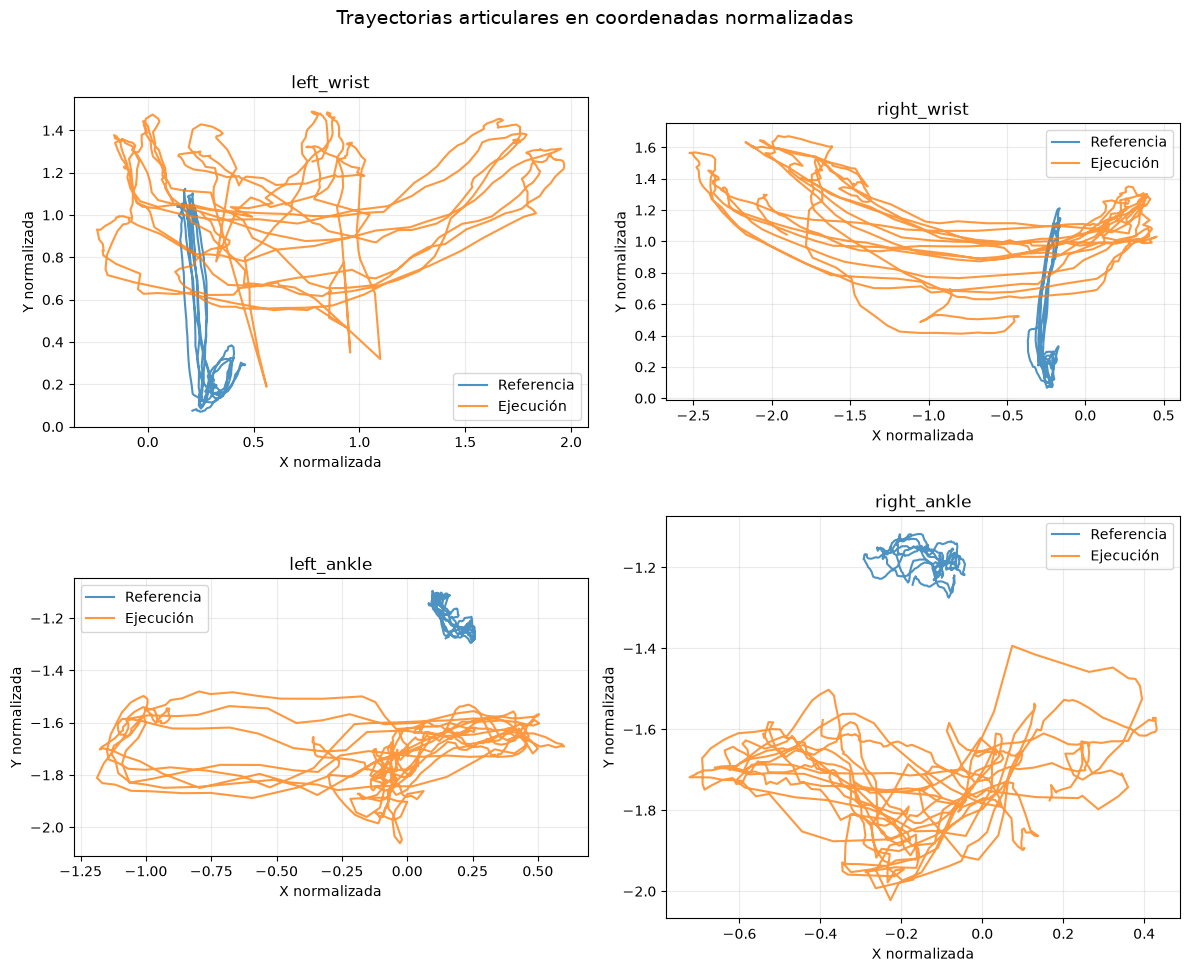

In [53]:
trajectory_landmark_names = [
    "left_wrist",
    "right_wrist",
    "left_ankle",
    "right_ankle",
]

def landmark_by_name(frame, landmark_name):
    return next(landmark for landmark in frame["landmarks"] if landmark["landmark_name"] == landmark_name)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for axis, landmark_name in zip(axes, trajectory_landmark_names):
    reference_points = [landmark_by_name(reference_frames_by_index[frame_index], landmark_name) for frame_index in comparable_frame_indices]
    execution_points = [landmark_by_name(execution_frames_by_index[frame_index], landmark_name) for frame_index in comparable_frame_indices]
    axis.plot([point["x"] for point in reference_points], [-point["y"] for point in reference_points], label="Referencia", alpha=0.8)
    axis.plot([point["x"] for point in execution_points], [-point["y"] for point in execution_points], label="Ejecución", alpha=0.8)
    axis.set_title(landmark_name)
    axis.set_xlabel("X normalizada")
    axis.set_ylabel("Y normalizada")
    axis.set_aspect("equal")
    axis.grid(alpha=0.25)
    axis.legend()

fig.suptitle("Trayectorias articulares en coordenadas normalizadas", fontsize=14)

plt.tight_layout()
plt.show()

### Interpretación y limitaciones de las trayectorias

Las trayectorias muestran diferencias importantes entre referencia y ejecución,
especialmente en muñecas y tobillos.

Estas diferencias pueden deberse a una combinación de movimiento, orientación
corporal, perspectiva de cámara, encuadre y distinta velocidad de ejecución.

La normalización aplicada corrige traslación y escala, pero no elimina por
completo los efectos de rotación ni de perspectiva. Por ello, esta
visualización se considera exploratoria y no se utilizará todavía para emitir
una conclusión de desempeño.

La comparación definitiva requerirá revisar la orientación corporal y aplicar
alineación temporal mediante DTW.

## 12. Diagnóstico de orientación corporal

Antes de construir el mapa de diferencias, se revisará si existe una
orientación corporal distinta entre referencia y ejecución.

Se utilizará la línea de los hombros como indicador aproximado de inclinación.
Esta medida no identifica por sí sola el ángulo de la cámara, pero ayuda a
detectar diferencias sistemáticas de orientación o encuadre.

El resultado se interpretará como diagnóstico técnico, no como una métrica de
desempeño.

Diferencia angular promedio de orientación: 10.75 grados


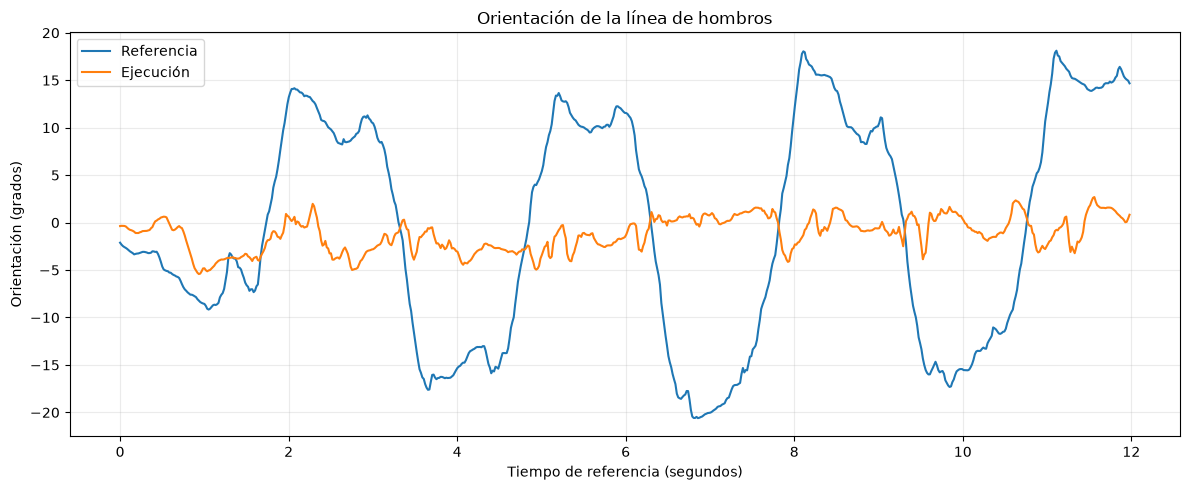

In [54]:
def shoulder_orientation_deg(frame):
    left_shoulder = landmark_by_name(frame, "left_shoulder")
    right_shoulder = landmark_by_name(frame, "right_shoulder")

    delta_x = left_shoulder["x"] - right_shoulder["x"]
    delta_y = -(left_shoulder["y"] - right_shoulder["y"])

    return math.degrees(math.atan2(delta_y, delta_x))


orientation_records = []

for frame_index in comparable_frame_indices:
    reference_orientation = shoulder_orientation_deg(reference_frames_by_index[frame_index])
    execution_orientation = shoulder_orientation_deg(execution_frames_by_index[frame_index])

    orientation_records.append({
        "frame_index": frame_index,
        "reference_timestamp_sec": reference_frames_by_index[frame_index]["timestamp_sec"],
        "reference_orientation_deg": reference_orientation,
        "execution_orientation_deg": execution_orientation,
        "absolute_difference_deg": abs(reference_orientation - execution_orientation)
    })

orientation_timestamps = [record["reference_timestamp_sec"] for record in orientation_records]

reference_orientations = [record["reference_orientation_deg"] for record in orientation_records]

execution_orientations = [record["execution_orientation_deg"] for record in orientation_records]

orientation_differences = [record["absolute_difference_deg"] for record in orientation_records]

print("Diferencia angular promedio de orientación:",round(sum(orientation_differences) / len(orientation_differences), 2), "grados",)

plt.figure(figsize=(12, 5))
plt.plot(orientation_timestamps, reference_orientations, label="Referencia",)
plt.plot(orientation_timestamps, execution_orientations, label="Ejecución",)
plt.title("Orientación de la línea de hombros")
plt.xlabel("Tiempo de referencia (segundos)")
plt.ylabel("Orientación (grados)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretación de la orientación corporal

La ejecución presenta una orientación de hombros más estable y cercana a cero, mientras que la referencia muestra variaciones amplias durante la secuencia.

Esto indica que la diferencia observada puede combinar efectos de cámara, orientación corporal y falta de alineación temporal. La normalización actual no corrige rotación ni perspectiva, por lo que esta variable se conservará como diagnóstico y no como corrección automática.

## 13. Mapa corporal de diferencias

Se resumirá la diferencia promedio de cada landmark y se representará sobre un esqueleto normalizado de referencia.

El color indicará qué landmarks presentan mayor diferencia geométrica en el conjunto de frames comparables.

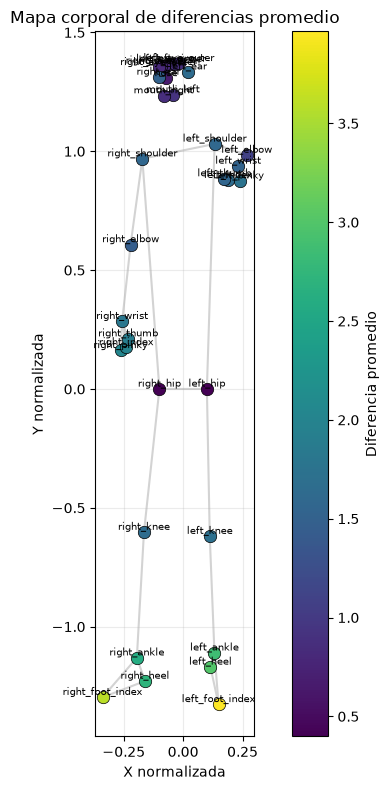

In [55]:
landmark_difference_by_name = defaultdict(list)

for record in coordinate_difference_records:
    landmark_difference_by_name[record["landmark_name"]].append(record["distance_3d"])

landmark_difference_summary = {landmark_name: sum(values) / len(values) for landmark_name, values in landmark_difference_by_name.items()}

selected_reference_frame = reference_frames_by_index[comparison_frame_index]

selected_landmarks = landmarks_by_id(selected_reference_frame)

difference_values = list(landmark_difference_summary.values())

minimum_difference = min(difference_values)
maximum_difference = max(difference_values)
difference_range = maximum_difference - minimum_difference

fig, axis = plt.subplots(figsize=(8, 8))

for start_id, end_id in POSE_CONNECTIONS:
    if start_id not in selected_landmarks or end_id not in selected_landmarks:
        continue
    start = selected_landmarks[start_id]
    end = selected_landmarks[end_id]
    axis.plot([start["x"], end["x"]], [-start["y"], -end["y"]], color="lightgray", linewidth=1.5, zorder=1)

for landmark in selected_landmarks.values():
    landmark_name = landmark["landmark_name"]
    difference = landmark_difference_summary[landmark_name]
    normalized_difference = ((difference - minimum_difference) / difference_range if difference_range > 0 else 0.5)
    axis.scatter(landmark["x"], -landmark["y"], s=80, color=plt.cm.viridis(normalized_difference), edgecolor="black", linewidth=0.5, zorder=2)
    axis.text(landmark["x"], -landmark["y"], landmark_name, fontsize=7, ha="center", va="bottom")

axis.set_title("Mapa corporal de diferencias promedio")
axis.set_xlabel("X normalizada")
axis.set_ylabel("Y normalizada")
axis.set_aspect("equal")
axis.grid(alpha=0.25)
scalar_map = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=minimum_difference, vmax=maximum_difference))
scalar_map.set_array([])
fig.colorbar(scalar_map, ax=axis, label="Diferencia promedio",)
plt.tight_layout()
plt.show()

### Mapa corporal enfocado en las mayores diferencias

Para facilitar la interpretación, se mostrarán únicamente los diez landmarks con mayor diferencia promedio.

El esqueleto completo se conservará como referencia visual, pero solo los landmarks destacados tendrán etiquetas y colores intensos.

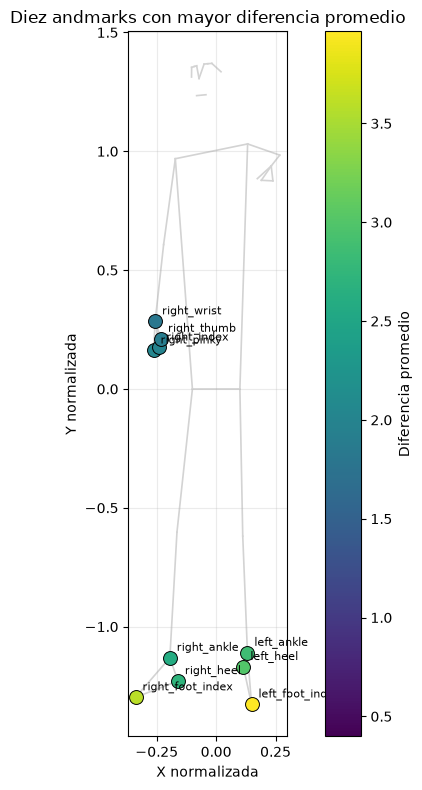

In [58]:
top_landmark_names = [landmark_name for landmark_name, _ in sorted(landmark_difference_summary.items(), key=lambda item: item[1], reverse=True,)[:10]]

fig, axis = plt.subplots(figsize=(8, 8))

for start_id, end_id in POSE_CONNECTIONS:
    if start_id not in selected_landmarks or end_id not in selected_landmarks:
        continue

    start = selected_landmarks[start_id]
    end = selected_landmarks[end_id]

    axis.plot([start["x"], end["x"]], [-start["y"], -end["y"]], color="lightgray", linewidth=1.2, zorder=1)

for landmark_name in top_landmark_names:
    landmark = next(landmark for landmark in selected_landmarks.values() if landmark["landmark_name"] == landmark_name)
    
    difference = landmark_difference_summary[landmark_name]
    normalized_difference = ((difference - minimum_difference) / difference_range if difference_range > 0 else 0.5)
    
    axis.scatter(landmark["x"], -landmark["y"], s=100, color=plt.cm.viridis(normalized_difference), edgecolor="black", linewidth=0.7, zorder=2)
    axis.annotate(landmark_name, (landmark["x"], -landmark["y"]), xytext=(5, 5), textcoords="offset points", fontsize=8)

axis.set_title("Diez andmarks con mayor diferencia promedio")
axis.set_xlabel("X normalizada")
axis.set_ylabel("Y normalizada")
axis.set_aspect("equal")
axis.grid(alpha=0.25)

scalar_map = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=minimum_difference, vmax=maximum_difference))

scalar_map.set_array([])

fig.colorbar(scalar_map, ax=axis, label="Diferencia promedio",)

plt.tight_layout()
plt.show()

## 14. Tabla preliminar de hallazgos

Se construirá una tabla con las diferencias más altas observadas durante la comparación directa.

La tabla incluirá:

- tiempo de referencia;
- tiempo de ejecución;
- segmento temporal preliminar;
- landmark o articulación;
- parte del cuerpo;
- diferencia;
- severidad descriptiva;
- recomendación candidata.

La severidad y las recomendaciones son preliminares. Las reglas definitivas se implementarán en el Notebook 06.

In [59]:
from html import escape
from IPython.display import HTML, display

all_coordinate_differences = [record["distance_3d"] for record in coordinate_difference_records]

sorted_differences = sorted(all_coordinate_differences)

def percentile(values, proportion):
    index = int((len(values) - 1) * proportion)
    return values[index]

medium_threshold = percentile(sorted_differences, 0.50)
high_threshold = percentile(sorted_differences, 0.80)

recommendations_by_body_part = {
    "head": "Revisar la orientación de la cabeza.",
    "torso": "Revisar la inclinación y estabilidad del torso.",
    "left_arm": "Revisar la trayectoria del brazo izquierdo.",
    "right_arm": "Revisar la trayectoria del brazo derecho.",
    "left_leg": "Revisar la posición y trayectoria de la pierna izquierda.",
    "right_leg": "Revisar la posición y trayectoria de la pierna derecha.",
}

def classify_difference(value):
    if value >= high_threshold:
        return "Alta"
    if value >= medium_threshold:
        return "Media"
    return "Baja"

sorted_records = sorted(coordinate_difference_records, key=lambda record: record["distance_3d"], reverse=True,)

finding_records = []

for record in sorted_records[:20]:
    reference_time = record["reference_timestamp_sec"]
    execution_time = record["execution_timestamp_sec"]
    body_part = record["body_part"]

    finding_records.append({
        "tiempo_referencia_sec": round(reference_time, 3),
        "tiempo_ejecucion_sec": round(execution_time, 3),
        "segmento_preliminar": f"{int(reference_time)}-{int(reference_time) + 1}s",
        "landmark": record["landmark_name"],
        "parte_cuerpo": body_part,
        "diferencia_3d": round(record["distance_3d"], 4),
        "severidad": classify_difference(record["distance_3d"]),
        "recomendacion_candidata": recommendations_by_body_part[body_part]
    })

table_headers = [
    "tiempo_referencia_sec",
    "tiempo_ejecucion_sec",
    "segmento_preliminar",
    "landmark",
    "parte_cuerpo",
    "diferencia_3d",
    "severidad",
    "recomendacion_candidata",
]

table_html = "<table><thead><tr>"
table_html += "".join(f"<th>{escape(header)}</th>" for header in table_headers)
table_html += "</tr></thead><tbody>"

for record in finding_records:
    table_html += "<tr>"
    table_html += "".join( f"<td>{escape(str(record[header]))}</td>" for header in table_headers)
    table_html += "</tr>"

table_html += "</tbody></table>"

display(HTML(table_html))

tiempo_referencia_sec,tiempo_ejecucion_sec,segmento_preliminar,landmark,parte_cuerpo,diferencia_3d,severidad,recomendacion_candidata
1.718,1.717,1-2s,left_foot_index,left_leg,8.1825,Alta,Revisar la posición y trayectoria de la pierna izquierda.
1.685,1.684,1-2s,left_foot_index,left_leg,7.9342,Alta,Revisar la posición y trayectoria de la pierna izquierda.
7.107,7.103,7-8s,left_foot_index,left_leg,7.8538,Alta,Revisar la posición y trayectoria de la pierna izquierda.
1.735,1.734,1-2s,left_foot_index,left_leg,7.7411,Alta,Revisar la posición y trayectoria de la pierna izquierda.
1.702,1.701,1-2s,left_foot_index,left_leg,7.6526,Alta,Revisar la posición y trayectoria de la pierna izquierda.
7.09,7.086,7-8s,left_foot_index,left_leg,7.6114,Alta,Revisar la posición y trayectoria de la pierna izquierda.
1.668,1.667,1-2s,left_foot_index,left_leg,7.4603,Alta,Revisar la posición y trayectoria de la pierna izquierda.
1.818,1.817,1-2s,left_foot_index,left_leg,7.4252,Alta,Revisar la posición y trayectoria de la pierna izquierda.
10.127,10.121,10-11s,left_foot_index,left_leg,7.3862,Alta,Revisar la posición y trayectoria de la pierna izquierda.
10.11,10.104,10-11s,left_foot_index,left_leg,7.3513,Alta,Revisar la posición y trayectoria de la pierna izquierda.


## 15. Exportación de resultados de comparación

Se guardará un resumen estructurado de la comparación inicial para conservar las métricas, diferencias por parte del cuerpo, diferencias angulares y tabla de hallazgos.

Este resultado será una salida preliminar del Notebook 04. La alineación DTW, el score temporal y las reglas finales se agregarán en notebooks posteriores.

In [60]:
COMPARISON_DIR = PROJECT_ROOT / "data" / "derived" / "comparison"
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

orientation_mean_difference = (sum(orientation_differences) / len(orientation_differences))

comparison_summary = {
    "reference_video": reference_features["source_video"],
    "execution_video": execution_features["source_video"],
    "reference_role": reference_features["video_role"],
    "execution_role": execution_features["video_role"],
    "reference_frame_count": reference_features["frame_count"],
    "execution_frame_count": execution_features["frame_count"],
    "reference_fps": reference_features["fps"],
    "execution_fps": execution_features["fps"],
    "common_frame_count": len(common_frame_indices),
    "comparable_frame_count": len(comparable_frame_indices),
    "coordinate_difference_by_body_part": body_part_difference_summary,
    "angle_difference_summary": angle_difference_summary,
    "orientation_summary": {
        "mean_difference_deg": round(orientation_mean_difference, 4),
        "max_difference_deg": round(max(orientation_differences), 4),
    },
    "preliminary_findings": finding_records,
    "notes": [
        "Comparación directa por índice de frame.",
        "La alineación temporal DTW aún no se ha aplicado.",
        "Las severidades y recomendaciones son preliminares.",
        "No representa una evaluación profesional de danza.",
    ],
}

comparison_output_path = (COMPARISON_DIR / "pose_comparison_summary.json")

with comparison_output_path.open("w", encoding="utf-8") as file:
    json.dump(comparison_summary, file, ensure_ascii=False, indent=2)

print(f"Resumen guardado en: {comparison_output_path}")
print("Hallazgos exportados:", len(finding_records))

Resumen guardado en: /Users/igayvid/Library/Mobile Documents/com~apple~CloudDocs/Documents/05-aprendizaje/diplomado-ciencia-datos/05-modulo-integrador/mitotl-ia/data/derived/comparison/pose_comparison_summary.json
Hallazgos exportados: 20


## 16. Conclusiones y limitaciones

La comparación inicial permitió calcular diferencias de coordenadas normalizadas, diferencias angulares, trayectorias articulares y diferencias por parte del cuerpo entre una referencia y una ejecución propia.

Se observaron mayores diferencias promedio en las piernas y los brazos. Las diferencias angulares más relevantes aparecieron en los hombros. También se identificó una diferencia de orientación corporal que puede estar relacionada con el ángulo de cámara, el encuadre, la postura o la falta de alineación temporal.

Estos resultados son exploratorios. La comparación se realizó por índice de frame y todavía no utiliza DTW. Por lo tanto, las severidades y recomendaciones candidatas no representan conclusiones definitivas sobre el desempeño de la persona.

El Notebook 05 implementará la alineación temporal, la identificación de momentos equivalentes y la segmentación de la coreografía.

In [61]:
with comparison_output_path.open("r", encoding="utf-8") as file:
    saved_comparison_summary = json.load(file)

required_summary_fields = {
    "reference_video",
    "execution_video",
    "common_frame_count",
    "comparable_frame_count",
    "coordinate_difference_by_body_part",
    "angle_difference_summary",
    "orientation_summary",
    "preliminary_findings",
}

missing_summary_fields = (required_summary_fields - set(saved_comparison_summary))

if missing_summary_fields:
    raise ValueError(f"Faltan campos en el resumen: {missing_summary_fields}")

print("Resumen de comparación validado correctamente")
print("Frames comparables:", saved_comparison_summary["comparable_frame_count"])
print("Hallazgos:", len(saved_comparison_summary["preliminary_findings"]))

Resumen de comparación validado correctamente
Frames comparables: 719
Hallazgos: 20
